In [1]:
# Cellule 1 : Imports et configuration
%load_ext autoreload
%autoreload 2

import pandas as pd

# Import des classe et fonctions personnalisées
from tools.OI_class_OP import OI_DataProcessor
from tools.OI_utils import extract_xls,analyser_correlation_croisee

# Configuration de l'affichage pour voir toutes les colonnes
pd.set_option('display.max_columns', None)

In [2]:
tags = [
        {'tag':'WQ33222VA', 'nom':'ester_cons','info':'Totalisation du Peson Acetate/Propionate','unit':'t' },
        {'tag':'3340_type', 'nom':'A/P','info':'Acetate ou Propionate','unit':'t' },
        {'tag':'CTY_ACV43A_Teneur Vit. A (UV)', 'nom':'Acetate_UV','info':'ACV43A teneur en acetate'},
        {'tag':'CTY_A3340FGB_Teneur arr. Vit. A (UV)', 'nom':'Propionate_UV', 'info':'A3340FGB teneur en propionate'},
        {'tag':'PU3310VA_Sign','nom':'PU3310','info':'signature du PU3310'},
        {'tag':'PU3320VA_Sign','nom':'PU3320','info':'signature du PU3320'},
        {'tag':'PU3340VA_Sign','nom':'PU3340','info':'signature du PU3340'},
        {'tag':'FQ32202VA_UV','nom':'Hexane','info':'VA diluée dans de l\'hexane'},
        {'tag':'CTY_A3230A_Teneur en rétinol', 'nom':'Retinol_UV','info':'A3230A teneur en rétinol lavé'},
        {'tag':'LI33203VA','nom':'R33020','info':'niveau du R33020'},
        {'tag':'LI33218VA','nom':'R33022','info':'niveau du R33022'},
        {'tag':'LI33225VA','nom':'R33061','info':'niveau du R33061'},
        {'tag':'WI33222VA','nom':'R33060','info':'peson du R33060'},
        {'tag':'FQ32202VA','nom':'retinol_cons','info':'Consommation rétinol phase Ester'},
    ]

In [3]:
old_produits = [
    { 'batchs' : [
        {'tag':'PU3310', 'min':540, 'max':710, 'value':'Hexane', 'uv':'Retinol_UV', 'scale':1/825/100., 'default':2.71, 'cond':None, 'val_cond': None},
        {'tag':'PU3310', 'min':710, 'max':2320, 'value':None, 'uv':None, 'scale':2.71, 'default':0, 'cond':None, 'val_cond':None},
        {'tag':'PU3320', 'min':430, 'max':2020, 'value':None, 'uv':None, 'scale':2.71, 'default':0, 'cond':None, 'val_cond':None},
        {'tag':'PU3340', 'min':0, 'max':710, 'value':'R33060', 'uv':None, 'scale':0.95, 'default':0, 'cond':'A/P', 'val_cond':[1/344,1/359]},
    ],
     'continus' : [
        {'tag':'R33020', 'min': 14,  'epalage': [[28.62,21.22,3.866,-0.0983], [-228.84,74.557]], 'uv':'Retinol_UV', 'scale':1/100., 'cond':'A/P', 'val_cond':[1/344,1/359] },
        {'tag':'R33022', 'min': 14,  'epalage': [[6.25,5.4525,0.898,-0.0256], [-35,97,16.039]], 'uv':'Retinol_UV', 'scale':1/100., 'cond':'A/P', 'val_cond':[1/344,1/359] },
        {'tag':'R33061', 'min': 18,  'epalage': [[0.69,0.72,0.296,-0.0059], [-30.03,5.836]], 'uv':None, 'scale':0.95, 'cond':'A/P', 'val_cond':[1/344,1/359] },
    ] } ,
    { 'continus' : [
        {'tag': 'COUcou', 'min' :12 }
    ] }
]


In [4]:
produits = [
    {   'consommation' : 'ester_cons',
        'article' : 'Ester',
        'stocks' : [
        {'pu':'PU3310', 'in':540, 'out':710, 'value':'Hexane', 'uv':'Retinol_UV', 'scale':1/825/100., 'default':2.71, 'cond':None, 'val_cond': None},
        {'pu':'PU3310', 'in':710, 'out':2320, 'value':None, 'uv':None, 'scale':2.71, 'default':0, 'cond':None, 'val_cond':None},
        {'pu':'PU3320', 'in':430, 'out':2020, 'value':None, 'uv':None, 'scale':2.71, 'default':0, 'cond':None, 'val_cond':None},
        {'pu':'PU3340', 'in':0, 'out':710, 'value':'R33060', 'uv':None, 'scale':0.95, 'default':0, 'cond':'A/P', 'val_cond':[1/344,1/359]},
        {'pu':None, 'value':'R33020', 'min': 14,  'epalage': [[28.62,21.22,3.866,-0.0983], [-228.84,74.557]], 'uv':'Retinol_UV', 'scale':1/100., 'cond':'A/P', 'val_cond':[1/344,1/359] },
        {'pu':None, 'value':'R33022', 'min': 14,  'epalage': [[6.25,5.4525,0.898,-0.0256], [-35,97,16.039]], 'uv':'Retinol_UV', 'scale':1/100., 'cond':'A/P', 'val_cond':[1/344,1/359] },
        {'pu':None, 'value':'R33061', 'min': 18,  'epalage': [[0.69,0.72,0.296,-0.0059], [-30.03,5.836]], 'uv':None, 'scale':0.95, 'cond':'A/P', 'val_cond':[1/344,1/359] },
    ] },
    { 'stocks' : [
        {'tag': 'COUcou', 'min' :12 }
    ] }
]


In [5]:
# Initialisation
processor = OI_DataProcessor(
    url_base = 'https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?',
    tags_other = [],
    tags_selected = tags,
    start='2026-05-12',
    end='2026-05-14',
    interval='PT1H',
    verbose=False
)

# Charger les données
processor.merge()

# Appliquer des filtres (chaînage possible)
processor.filtering(
    tag=['ester_cons'],
    min_val=[0],
    max_val=[10_000_000],
    na=['ester_cons']
)

# Ajouter des colonnes
processor.ajoute_calcul('ester_cons','A/P','Acetate_UV','Propionate_UV',1e-9,produits[0]['article'])
#processor.ajoute_batch(batchs[3],'batchs')
#processor.ajoute_continus(continus[0],'continus')
processor.ajoute_all(produits[0]['stocks'],'stocks_ester')
#processor.ajoute_all_continus(produits[0]['continus'],'continus')
#processor.ajoute_cumul('A1000M_Poids', 'A1000M_UV_Auto', 1000, 'Cumul_UV')
#processor.ajouter_moyennes_glissantes_ponderee('A1000M_Poids', 'A1000M_UV_Auto', 'A1000M_Moyenne_UV', window=15)
#processor.ajouter_moyennes_glissantes('Acetate_UV', 'Acetate_Moyenne_UV', window=15)

# Afficher les infos finales
processor.info()
#processor.data

INFORMATIONS DataProcessor
URL de base       : https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?
Tags autres       : []
Tags sélectionnés : [{'tag': 'WQ33222VA', 'nom': 'ester_cons', 'info': 'Totalisation du Peson Acetate/Propionate', 'unit': 't'}, {'tag': '3340_type', 'nom': 'A/P', 'info': 'Acetate ou Propionate', 'unit': 't'}, {'tag': 'CTY_ACV43A_Teneur Vit. A (UV)', 'nom': 'Acetate_UV', 'info': 'ACV43A teneur en acetate'}, {'tag': 'CTY_A3340FGB_Teneur arr. Vit. A (UV)', 'nom': 'Propionate_UV', 'info': 'A3340FGB teneur en propionate'}, {'tag': 'PU3310VA_Sign', 'nom': 'PU3310', 'info': 'signature du PU3310'}, {'tag': 'PU3320VA_Sign', 'nom': 'PU3320', 'info': 'signature du PU3320'}, {'tag': 'PU3340VA_Sign', 'nom': 'PU3340', 'info': 'signature du PU3340'}, {'tag': 'FQ32202VA_UV', 'nom': 'Hexane', 'info': "VA diluée dans de l'hexane"}, {'tag': 'CTY_A3230A_Teneur en rétinol', 'nom': 'Retinol_UV', 'info': 'A3230A teneur en rétinol lavé'}, {'tag': 'LI33203VA', 'nom': 

In [13]:
# 1. On veut changer de date ?
processor.start = '2026-05-01'
processor.end = '2026-12-31'
processor.interval = 'PT10M'

# 2. On recalcule TOUT (merge + filtres + cumul) en une commande
processor.recalculate()

# 3. On vérifie le pipeline
processor.show_pipeline()
processor.info()
processor.data.describe()


--- PIPELINE ACTUEL ---
1. filtering | Args: () | Kwargs: {'tag': ['ester_cons'], 'min_val': [0], 'max_val': [10000000], 'na': ['ester_cons']}
2. ajoute_calcul | Args: ('ester_cons', 'A/P', 'Acetate_UV', 'Propionate_UV', 1e-09, 'Ester') | Kwargs: {}
3. ajoute_all | Args: ([{'pu': 'PU3310', 'in': 540, 'out': 710, 'value': 'Hexane', 'uv': 'Retinol_UV', 'scale': 1.2121212121212122e-05, 'default': 2.71, 'cond': None, 'val_cond': None}, {'pu': 'PU3310', 'in': 710, 'out': 2320, 'value': None, 'uv': None, 'scale': 2.71, 'default': 0, 'cond': None, 'val_cond': None}, {'pu': 'PU3320', 'in': 430, 'out': 2020, 'value': None, 'uv': None, 'scale': 2.71, 'default': 0, 'cond': None, 'val_cond': None}, {'pu': 'PU3340', 'in': 0, 'out': 710, 'value': 'R33060', 'uv': None, 'scale': 0.95, 'default': 0, 'cond': 'A/P', 'val_cond': [0.0029069767441860465, 0.002785515320334262]}, {'pu': None, 'value': 'R33020', 'min': 14, 'epalage': [[28.62, 21.22, 3.866, -0.0983], [-228.84, 74.557]], 'uv': 'Retinol_UV', 'sc

,ester_cons,A/P,Acetate_UV,Propionate_UV,PU3310,PU3320,PU3340,Hexane,Retinol_UV,R33020,R33022,R33061,R33060,retinol_cons,Ester,stocks_ester
count,4.051000e+03,4051.000000,4.051000e+03,4.051000e+03,4049.000000,4049.000000,4049.000000,4051.000000,4051.000000,4051.000000,4051.000000,4051.000000,4051.000000,4051.000000,4051.000000,4051.000000
mean,2.648838e+06,0.116903,2.252292e+06,2.288175e+06,1154.009610,1064.978422,469.448987,2873.798498,20.622734,50.103787,5.179677,7.931012,727.907416,515131.065789,123.924536,7.338697
std,3.121605e+04,0.321215,2.335718e+04,5.024794e+04,615.904907,530.151205,120.604573,1769.366940,0.150684,19.217179,2.526168,10.905294,316.810085,103388.265851,70.617419,1.596781
min,2.593880e+06,0.000000,2.204082e+06,2.188000e+06,100.000000,100.000000,216.233333,0.000000,20.400000,-7.023068,-0.691406,1.416328,32.882389,333796.000000,0.000000,0.845102
25%,2.622520e+06,0.000000,2.234690e+06,2.310000e+06,407.016667,403.200000,410.000000,137.242198,20.600000,34.302744,3.332153,3.127813,489.641370,428449.000000,64.222843,5.983609
50%,2.647400e+06,0.000000,2.252979e+06,2.314000e+06,1310.000000,1120.000000,410.000000,4011.196000,20.600000,51.541655,6.100241,3.784215,704.037070,510805.000000,120.584516,7.756330
75%,2.676270e+06,0.000000,2.264770e+06,2.314000e+06,1420.000000,1616.133333,410.000000,4054.280000,20.700000,67.380915,7.035614,4.906832,959.224596,606266.000000,185.858616,8.140548
max,2.700790e+06,1.000000,2.293140e+06,2.318000e+06,2320.100000,2250.466667,810.000000,4487.020000,20.900000,84.554912,8.699118,68.552560,1301.408500,684605.000000,241.604225,11.998836


In [7]:
def calcul_cumul_mensuel(processor, mois, annee=None, std=2):
    """
    Calcule le cumul, delta batch et delta continu pour un mois donne depuis processor.data.
    Le calcul s'effectue du 1er du mois a 3:00 au 1er du mois suivant a 3:00.
    Si le mois n'est pas termine, les valeurs sont calculees "a date" (jusqu'a la derniere donnee disponible).
    
    Parameters:
    -----------
    processor : OI_DataProcessor
        L'objet processor contenant le DataFrame data.
    mois : int, str
        Le mois a calculer. Peut etre un entier (ex: 5), une chaine (ex: '05', '2026-05', 'mai').
    annee : int, optional
        L'annee a calculer. Si non fournie, elle est deduite des donnees du processor (par defaut 2026).
        
    Returns:
    --------
    dict : Dictionnaire contenant les resultats du calcul.
    """
    df = processor.data
    if df is None or df.empty:
        print("Erreur : Les donnees du processeur (processor.data) sont vides.")
        return None
        
    # Deduction de l'annee si non specifiee
    if annee is None:
        annee = df.index.year[0]
        
    # Parsing du mois
    month_num = None
    if isinstance(mois, int):
        month_num = mois
    elif isinstance(mois, str):
        mois_clean = mois.strip().lower()
        if '-' in mois_clean:
            try:
                parts = mois_clean.split('-')
                annee = int(parts[0])
                month_num = int(parts[1])
            except ValueError:
                pass
        else:
            # Dictionnaire des mois en francais
            mois_fr = {
                'janvier': 1, 'jan': 1, 'fevrier': 2, 'fevrier': 2, 'fev': 2, 'fev': 2,
                'mars': 3, 'mar': 3, 'avril': 4, 'avr': 4, 'mai': 5, 'juin': 6, 'jui': 6,
                'juillet': 7, 'juil': 7, 'aout': 8, 'aout': 8, 'aou': 8, 'aou': 8,
                'septembre': 9, 'sept': 9, 'sep': 9, 'octobre': 10, 'oct': 10,
                'novembre': 11, 'nov': 11, 'decembre': 12, 'decembre': 12, 'dec': 12, 'dec': 12
            }
            if mois_clean in mois_fr:
                month_num = mois_fr[mois_clean]
            else:
                try:
                    month_num = int(mois_clean)
                except ValueError:
                    pass
                    
    if month_num is None or not (1 <= month_num <= 12):
        print(f"Erreur : Mois '{mois}' non valide. Utilisez un entier (1-12), un nom de mois en francais (ex: 'mai') ou 'AAAA-MM'.")
        return None

    # Definition des dates cibles a 3:00 du matin
    start_dt = pd.Timestamp(year=annee, month=month_num, day=1, hour=std, minute=0, second=0)
    
    if month_num == 12:
        end_dt = pd.Timestamp(year=annee + 1, month=1, day=1, hour=std, minute=0, second=0)
    else:
        end_dt = pd.Timestamp(year=annee, month=month_num + 1, day=1, hour=std, minute=0, second=0)
        
    # Gestion de la timezone si presente dans l'index
    if df.index.tz is not None:
        start_dt = start_dt.tz_localize(df.index.tz)
        end_dt = end_dt.tz_localize(df.index.tz)
        
    # Verification si le mois est termine ou "a date"
    last_dt = df.index[-1]
    is_finished = end_dt <= last_dt
    actual_end_dt = end_dt if is_finished else last_dt
    
    # Recherche des lignes correspondantes ou les plus proches
    try:
        # Date de debut
        if start_dt in df.index:
            row_start = df.loc[start_dt]
        else:
            # Plus proche index superieur ou egal a start_dt
            future_idx = df.index[df.index >= start_dt]
            if len(future_idx) == 0:
                print(f"Erreur : Aucune donnee disponible apres le debut du mois ({start_dt}).")
                return None
            row_start = df.loc[future_idx[0]]
            start_dt = future_idx[0]
            
        # Date de fin
        if actual_end_dt in df.index:
            row_end = df.loc[actual_end_dt]
        else:
            # Plus proche index inferieur ou egal a actual_end_dt
            past_idx = df.index[df.index <= actual_end_dt]
            if len(past_idx) == 0:
                print(f"Erreur : Aucune donnee disponible avant la fin du mois ({actual_end_dt}).")
                return None
            row_end = df.loc[past_idx[-1]]
            actual_end_dt = past_idx[-1]
            
    except Exception as e:
        print(f"Erreur lors de la recherche des dates dans l'index : {e}")
        return None
        
    # Calcul des deltas
    delta_cumul = row_end['Ester'] - row_start['Ester']
    delta_batch = row_end['stocks_ester'] - row_start['stocks_ester']
#    delta_continu = row_end['continus'] - row_start['continus']
    
    # Affichage des resultats
    status_str = "Termine" if is_finished else "A date (En cours)"
    nom_mois = ["Janvier", "Fevrier", "Mars", "Avril", "Mai", "Juin", "Juillet", "Aout", "Septembre", "Octobre", "Novembre", "Decembre"][month_num - 1]
    
    print("_" * 65)
    print(f"SUIVI MENSUEL - {nom_mois.upper()} {annee} ({status_str})")
    print("-" * 65)
    print(f"Periode calculee : du {start_dt.strftime('%d/%m/%Y a %H:%M')} au {actual_end_dt.strftime('%d/%m/%Y a %H:%M')}")
    print("_" * 65)
    print(f"Cumul (Ester)   : {delta_cumul:.4f}")
    print(f"Delta Batch     : {delta_batch:.4f}")
#    print(f"Delta Continu   : {delta_continu:.4f}")
    print("_" * 65)
#    print(f"Total Production : {delta_cumul + delta_batch + delta_continu:.4f}")
    print(f"Total Production : {delta_cumul + delta_batch :.4f}")
    print("_" * 65)
    
    return {
        'mois': f"{annee}-{month_num:02d}",
        'nom_mois': nom_mois,
        'status': status_str,
        'date_debut': start_dt,
        'date_fin': actual_end_dt,
        'delta_cumul': delta_cumul,
        'delta_batch': delta_batch,
#        'delta_continu': delta_continu,
        'total_production': delta_cumul + delta_batch
    }

In [14]:
# Exemple d'utilisation :
res = calcul_cumul_mensuel(processor, 5,std=2) # Calcul pour Mai à date
# res = calcul_cumul_mensuel(processor, '2026-05') # Equivalent

_________________________________________________________________
SUIVI MENSUEL - MAI 2026 (A date (En cours))
-----------------------------------------------------------------
Periode calculee : du 01/05/2026 a 02:00 au 29/05/2026 a 04:10
_________________________________________________________________
Cumul (Ester)   : 241.6042
Delta Batch     : -2.3938
_________________________________________________________________
Total Production : 239.2105
_________________________________________________________________


In [15]:
# Approche 1 : Simple - indexer par jour
jour1 = '2026-05-28 02:00:00'
data_jour1 = processor.data.loc[jour1]
jour2 = '2026-05-29 02:00:00'
data_jour2 = processor.data.loc[jour2]
delta_ester = data_jour2['Ester']-data_jour1['Ester']
delta_stocks = data_jour2['stocks_ester']-data_jour1['stocks_ester']
stock_j1 = data_jour1['stocks_ester']
stock_j2 = data_jour2['stocks_ester']
print('stocks : ', stock_j1, stock_j2)
print('delta Ester / Stocks',delta_ester, delta_stocks)
print('Production ',delta_ester + delta_stocks)
print(processor.data.loc[jour1], processor.data.loc[jour2])

stocks :  8.58474301392947 5.516148768891772
delta Ester / Stocks 8.431636609999998 -3.0685942450376986
Production  5.3630423649623
ester_cons       2.697050e+06
A/P              0.000000e+00
Acetate_UV       2.266089e+06
Propionate_UV    2.188000e+06
PU3310           2.320000e+03
PU3320           5.266900e+02
PU3340           4.100000e+02
Hexane           3.989060e+03
Retinol_UV       2.060000e+01
R33020           6.877099e+01
R33022           7.231908e+00
R33061           3.584615e+00
R33060           1.040277e+03
retinol_cons     6.764340e+05
Ester            2.331726e+02
stocks_ester     8.584743e+00
Name: 2026-05-28 02:00:00+00:00, dtype: float64 ester_cons       2.700790e+06
A/P              0.000000e+00
Acetate_UV       2.231260e+06
Propionate_UV    2.188000e+06
PU3310           1.257883e+03
PU3320           4.000000e+02
PU3340           4.100000e+02
Hexane           4.036490e+03
Retinol_UV       2.060000e+01
R33020           2.156103e+01
R33022           7.527340e+00
R33061    

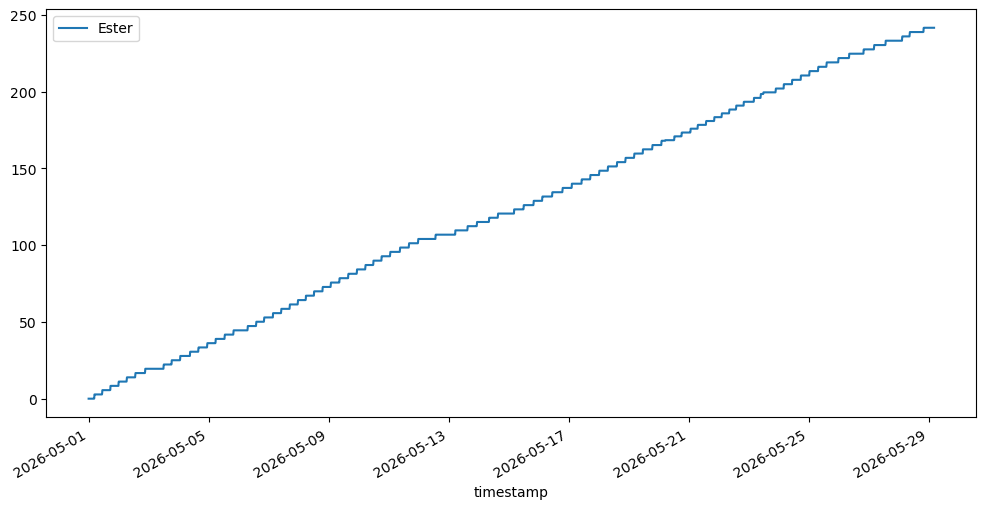

In [16]:
processor.data.plot(y=['Ester'], figsize=(12,6));

In [28]:
processor.plot_simple_tag(tag=['ester_cons'])